In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
import scipy.stats as stats
import matplotlib.pyplot as plt

In [30]:
df=pd.read_csv('/kaggle/input/datasets/brendan45774/test-file/tested.csv',usecols=['Age','Fare','Survived'])

In [31]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [32]:
si=SimpleImputer()
df['Age']=si.fit_transform(df[['Age']])
df['Fare']=si.fit_transform(df[['Fare']])

In [33]:
df.isnull().sum()


Survived    0
Age         0
Fare        0
dtype: int64

In [34]:
def apply_transform(transform):
    X=df.iloc[:,1:3]
    y=df.iloc[:,0]
    
    trf=ColumnTransformer([
        ('func',FunctionTransformer(transform),['Fare'])
    ],remainder='passthrough')
    
    X_trans=trf.fit_transform(X)
    
    clf=LogisticRegression()
    
    print("ACCURACY:",np.mean(cross_val_score(clf,X,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(X['Fare'],dist='norm',plot=plt)
    plt.title("Fare Before Transformatin")

    plt.subplot(122)
    stats.probplot(X_trans[:,0],dist='norm',plot=plt)
    plt.title("Fare After Transformatin")

ACCURACY: 0.6483739837398372


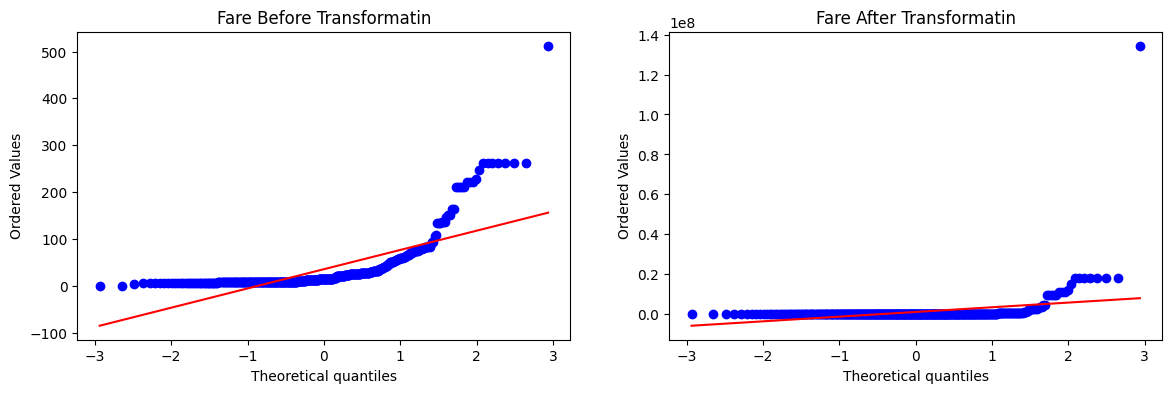

In [35]:
apply_transform(lambda x:x**3)